# EDA: Dataset Overview

## 1. Goal
Analyze the data schema and target distributions.

## 2. Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root
project_root = Path(os.getcwd()).parent.parent
sys.path.append(str(project_root))

from notebooks.config import *
sns.set_style(PLOT_STYLE)

## 3. Load Engineered Data

In [2]:
df = pd.read_parquet(CLEANED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8173, 55)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,junction,resolution_time_minutes,congestion_proxy_score,deployment_load_class,hour_of_day,day_of_week,is_weekend,is_peak_hour,priority_encoded,is_closed
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",None,vehicle_breakdown,False,...,None,NaN,3.00000,LOW,17,3,0,1,3,0
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",None,vehicle_breakdown,False,...,None,10.377589,3.17296,MEDIUM,4,1,0,0,3,0
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",None,others,False,...,UrvashiJunction,NaN,1.00000,LOW,6,5,1,0,1,0
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,True,...,None,NaN,8.00000,MEDIUM,17,3,0,1,1,1
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",None,vehicle_breakdown,False,...,LalbaghMainGateJunc,NaN,1.00000,LOW,4,1,0,0,1,0


## 4. Target Variables Analysis

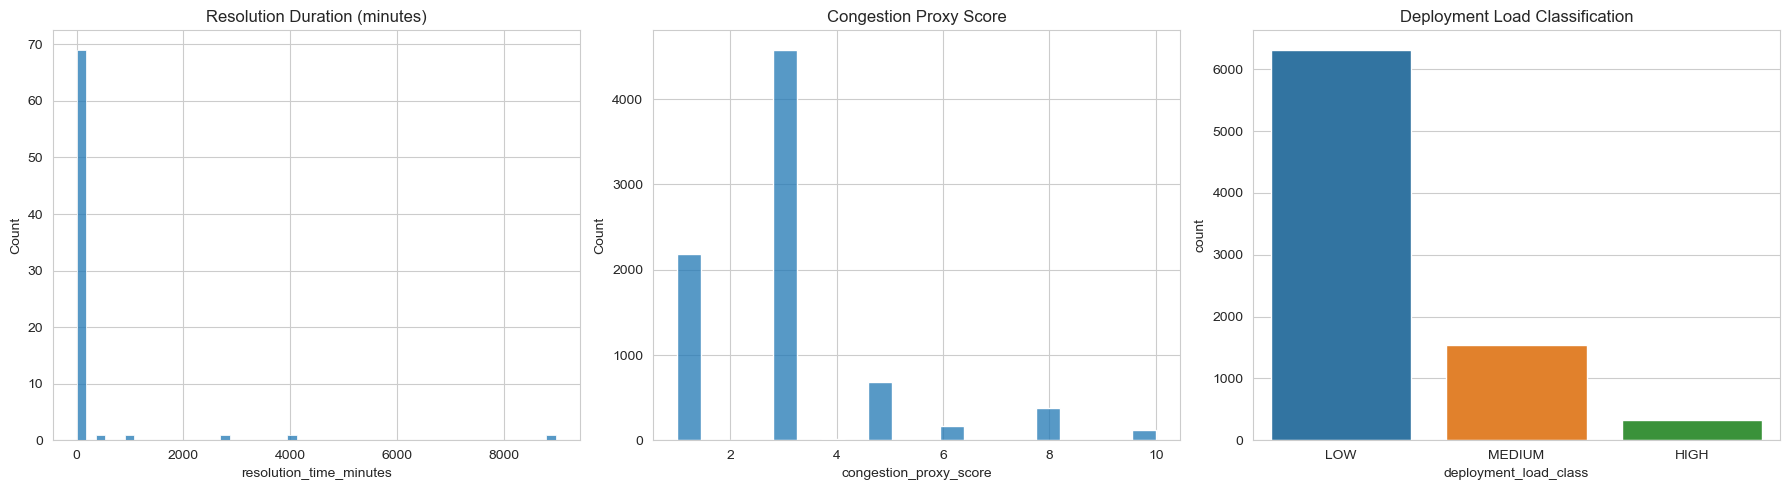

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df[RESPONSE_TIME_TARGET], bins=50, ax=axes[0])
axes[0].set_title("Resolution Duration (minutes)")

sns.histplot(df[CONGESTION_TARGET], bins=20, ax=axes[1])
axes[1].set_title("Congestion Proxy Score")

sns.countplot(x=df[DEPLOYMENT_TARGET], order=['LOW', 'MEDIUM', 'HIGH'], ax=axes[2])
axes[2].set_title("Deployment Load Classification")

plt.tight_layout()
plt.show()

## 5. Temporal Patterns

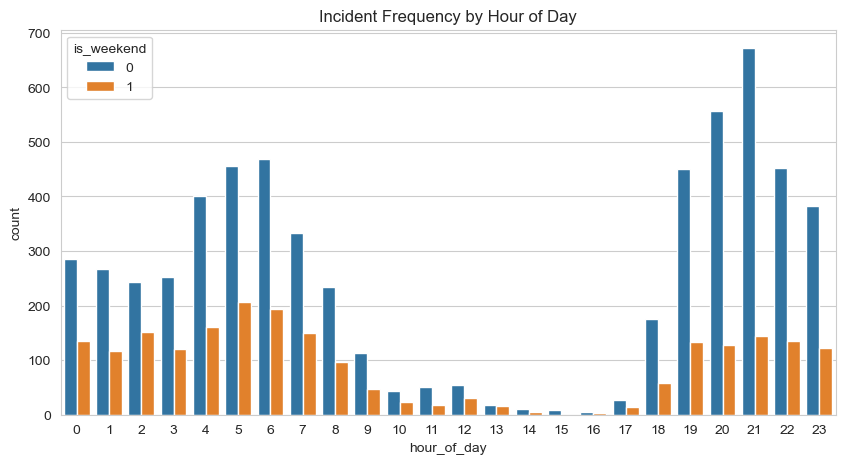

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(x='hour_of_day', data=df, hue='is_weekend')
plt.title("Incident Frequency by Hour of Day")
plt.show()